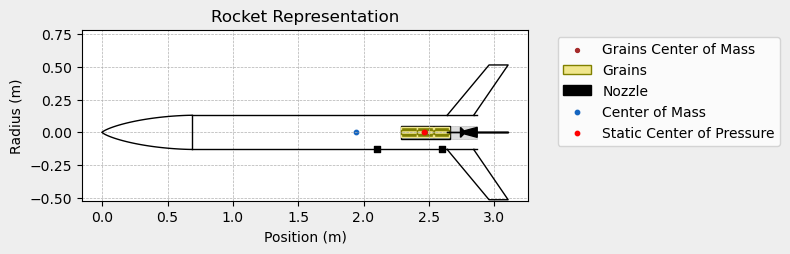

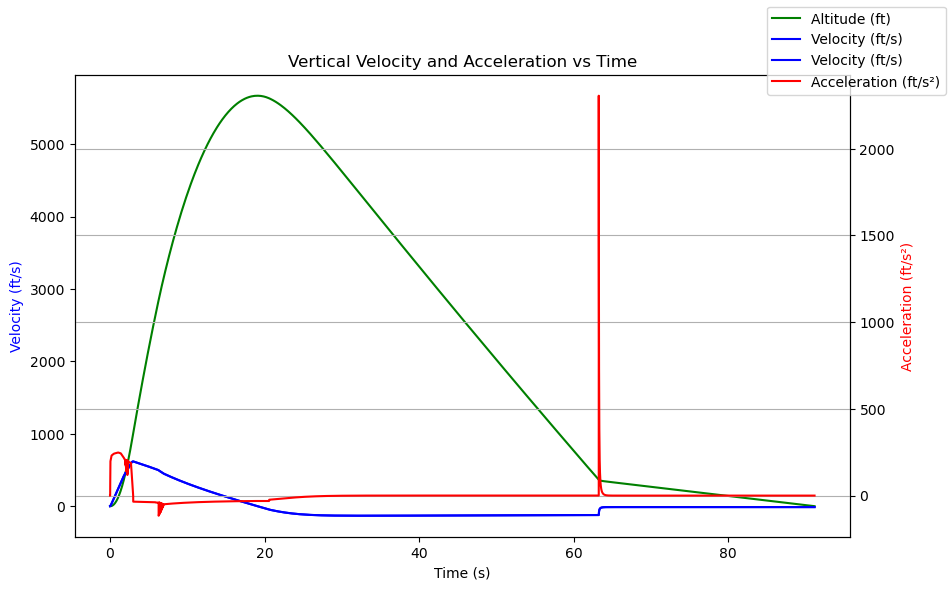

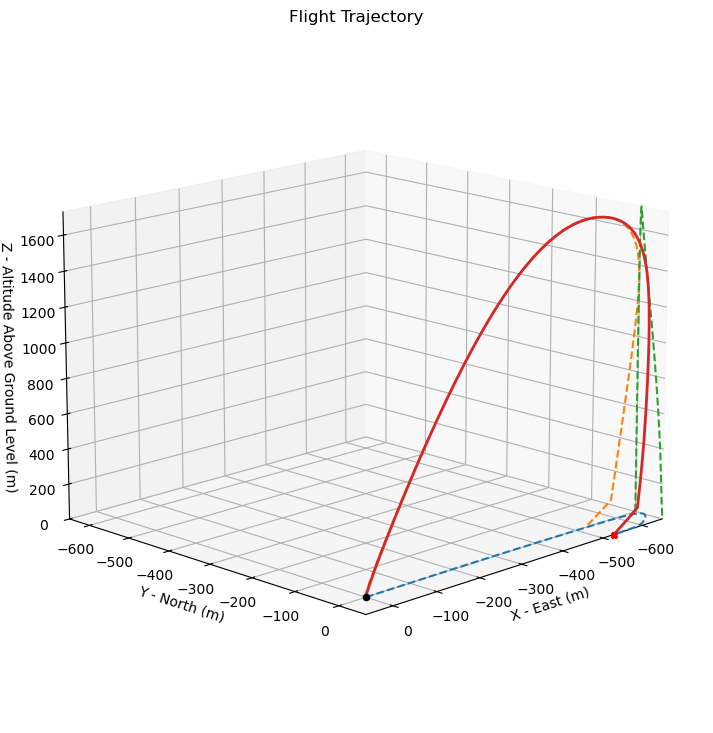

5668.289660834249
629.3020534296555
91.19457385291129
Lateral drift is 1742.0843111544693 (ft)


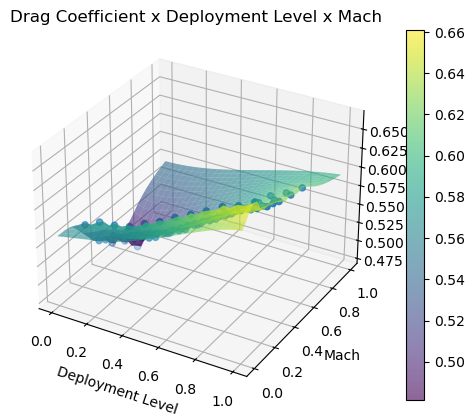

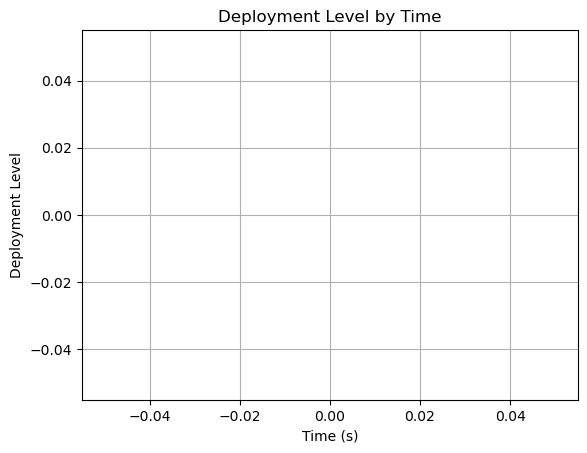

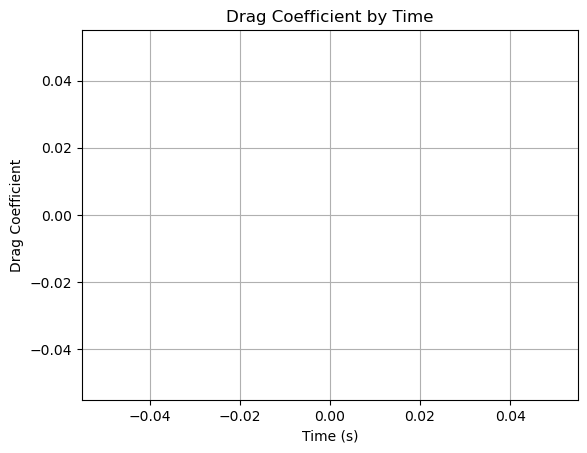

0
1727.6946333360509
3.0


In [ ]:
from rocketpy import Environment, SolidMotor, Rocket, Flight
import matplotlib.pyplot as plt
import numpy as np

#setting an environment
env_5 = Environment()
env_5.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=None,
    temperature=300,
    wind_u=[
        (0, 2.24), # 5 m/s at 0 m
        (2000, 2.24) # 10 m/s at 1000 m
    ],
    wind_v=[
        (0, 0), # -2 m/s at 0 m
        (700, 1.2), # 3 m/s at 500 m
        (2000, 2.5), # 2 m/s at 1000 m
    ],
)

huntsville = Environment()
#huntsville.set_date((2026, 4,27, 12))
#huntsville.set_atmospheric_model(type="Forecast", file="GFS")
#huntsville.info()


huntsville.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=None,
    temperature=300,
    wind_u=[
        (0, 2.24), # 5 m/s at 0 m
        (2000, 2.24) # 10 m/s at 1000 m
    ],
    wind_v=[
        (0, 0), # -2 m/s at 0 m
        (700, 1.2), # 3 m/s at 500 m
        (2000, 2.5), # 2 m/s at 1000 m
    ],
)

#10 mph env
env_10 = Environment()
env_10.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=None,
    temperature=300,
    wind_u=[
        (0, 4.48),
        (2000, 4.48) 
    ],
    wind_v=[
        (0, 0), # -2 m/s at 0 m
        (700, 2), # 3 m/s at 500 m
        (2000, 3.5), # 2 m/s at 1000 m
    ],
)

# #15 mpg env
# env_15 = Environment()
# env_15.set_atmospheric_model(
#     type="custom_atmosphere",
#     pressure=None,
#     temperature=300,
#     wind_u=[
#         (0, 6.72), # 5 m/s at 0 m
#         (2000, 6.72) # 10 m/s at 1000 m
#     ],
#     wind_v=[
#         (0, 0), # -2 m/s at 0 m
#         (700, 2.5), # 3 m/s at 500 m
#         (2000, 4), # 2 m/s at 1000 m
#     ],
# )

# #20 mph env
# env_20 = Environment()
# env_20.set_atmospheric_model(
#     type="custom_atmosphere",
#     pressure=None,
#     temperature=300,
#     wind_u=[
#         (0, 9.96), # 5 m/s at 0 m
#         (2000, 9.96) # 10 m/s at 1000 m
#     ],
#     wind_v=[
#         (0, 0), # -2 m/s at 0 m
#         (700, 3), # 3 m/s at 500 m
#         (2000, 4.5), # 2 m/s at 1000 m
#     ],
# )

#Setting a motor
L1256 = SolidMotor(
    thrust_source="AeroTech_L1256WS.eng",
    dry_mass=1.929,
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=38 / 1000,
    grain_number=3,
    grain_density=1750,
    grain_outer_radius=38 / 1000,
    grain_initial_inner_radius=15 / 1000,
    grain_initial_height=120 / 1000,
    grain_separation=5/1000,
    grains_center_of_mass_position=0.397,
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    burn_time=3.0,
    throat_radius=11 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

#Setting a rocket
CANTELOUPE = Rocket(
    radius=.13081,
    mass=13.24,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag="drag.csv",
    power_on_drag="drag.csv",
    center_of_mass_without_motor=1.755,
    coordinate_system_orientation="nose_to_tail",
)

#add motor
CANTELOUPE.add_motor(L1256, position=2.87)

#nose cone
nose_cone = CANTELOUPE.add_nose(
    length=0.686, kind="lvhaack", position=0
)

#fins
fin_set = CANTELOUPE.add_trapezoidal_fins(
    n=4,
    root_chord=0.203,
    tip_chord=0.146,
    span=0.385,
    position=2.64,
    sweep_angle=39.8,
)

#main parachute
main = CANTELOUPE.add_parachute(
    name="Main",
    cd_s=17.11,
    trigger=167.64,
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=1.22,
    height=1.22,
    porosity=0.0432,
)

#drogue parachute
drogue = CANTELOUPE.add_parachute(
    name="Drogue",
    cd_s=.1824,
    trigger="apogee",
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
    radius=.254,
    height=.254,
    porosity=0.0432,
)

rail_buttons = CANTELOUPE.set_rail_buttons(
upper_button_position=2.1,
lower_button_position=2.6,
angular_position=45,
)

#Drawing
CANTELOUPE.draw()

#ATS


#flight conditions
flight = Flight(
    rocket=CANTELOUPE, environment=env_5, rail_length=3.6576, inclination=85, heading=270)

# flight_10 = Flight(
#     rocket=CANTELOUPE, environment=env_10, rail_length=3.6576, inclination=85, heading=270
#     )

# flight_15 = Flight(
#     rocket=CANTELOUPE, environment=env_15, rail_length=3.6576, inclination=85, heading=270
#     )

# flight_20 = Flight(
#     rocket=CANTELOUPE, environment=env_20, rail_length=3.6576, inclination=85, heading=270
#     )

#2d Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(flight.time, flight.z[:, 1] * 3.28084, color='green', label='Altitude (ft)')
ax1.plot(flight.time, flight.vz[:, 1] * 3.28084, color='blue', label='Velocity (ft/s)')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Altitude (ft) / Velocity (ft/s)")

ax1.plot(flight.time, flight.vz[:, 1] * 3.28084, color='blue', label='Velocity (ft/s)')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Velocity (ft/s)", color='blue')

ax2 = ax1.twinx()
ax2.plot(flight.time, flight.az[:, 1] * 3.28084, color='red', label='Acceleration (ft/s²)')
ax2.set_ylabel("Acceleration (ft/s²)", color='red')

fig.legend(loc='upper right')
plt.title("Vertical Velocity and Acceleration vs Time")
plt.grid(True)
plt.show()

#3d plot 5
flight.plots.trajectory_3d()

print(flight.apogee * 3.28084)

print(flight.max_speed * 3.28084)

print(flight.t_final)


#Drift calculation 5
impact_coordinates = (flight.x_impact, flight.y_impact)
drift = np.sqrt(flight.x_impact**2 + flight.y_impact**2) * 3.281
print(f"Lateral drift is {drift} (ft)")


# #10 mph
# flight_10.plots.trajectory_3d()

# print(flight_10.apogee * 3.28084)

# print(flight_10.max_speed * 3.28084)

# print(flight_10.t_final)

# #Drift calculation
# impact_coordinates = (flight_10.x_impact, flight_10.y_impact)
# drift_10 = np.sqrt(flight_10.x_impact**2 + flight_10.y_impact**2) * 3.281
# print(f"Lateral drift is {drift_10} (ft)")

# #15 mph
# flight_15.plots.trajectory_3d()

# print(flight_15.apogee * 3.28084)

# print(flight_15.max_speed * 3.28084)

# print(flight_15.t_final)

# #Drift calculation
# impact_coordinates = (flight_15.x_impact, flight_15.y_impact)
# drift_15 = np.sqrt(flight_15.x_impact**2 + flight_15.y_impact**2) * 3.281
# print(f"Lateral drift is {drift_15} (ft)")

# #20 mph
# flight_20.plots.trajectory_3d()

# print(flight_20.apogee * 3.28084)

# print(flight_20.max_speed * 3.28084)

# print(flight_20.t_final)

# #Drift calculation
# impact_coordinates = (flight_20.x_impact, flight_20.y_impact)
# drift_20 = np.sqrt(flight_20.x_impact**2 + flight_20.y_impact**2) * 3.281
# print(f"Lateral drift is {drift_20} (ft)")


#ats stuff

def controller_function(
    time, sampling_rate, state, state_history, observed_variables, air_brakes
):
    # state = [x, y, z, vx, vy, vz, e0, e1, e2, e3, wx, wy, wz]
    altitude_ASL = state[2]
    altitude_AGL = altitude_ASL - huntsville.elevation
    vx, vy, vz = state[3], state[4], state[5]

    # Get winds in x and y directions
    wind_x, wind_y = huntsville.wind_velocity_x(altitude_ASL), huntsville.wind_velocity_y(altitude_ASL)

    # Calculate Mach number
    free_stream_speed = (
        (wind_x - vx) ** 2 + (wind_y - vy) ** 2 + (vz) ** 2
    ) ** 0.5
    mach_number = free_stream_speed / huntsville.speed_of_sound(altitude_ASL)

    # Get previous state from state_history
    previous_state = state_history[-1]
    previous_vz = previous_state[5]

    # If we wanted to we could get the returned values from observed_variables:
    # returned_time, deployment_level, drag_coefficient = observed_variables[-1]

    # Check if the rocket has reached burnout
    if time < L1256.burn_out_time:
        return None

    # If below 1500 meters above ground level, air_brakes are not deployed
    if altitude_AGL < 200:
        air_brakes.deployment_level = 0
        return (time, 0, air_brakes.drag_coefficient(0, mach_number))

    # Else calculate the deployment level
    else:
        # Controller logic
        new_deployment_level = (
            air_brakes.deployment_level + 0.1 * vz + 0.01 * previous_vz**2
        )

        # Limiting the speed of the air_brakes to 0.2 per second
        # Since this function is called every 1/sampling_rate seconds
        # the max change in deployment level per call is 0.2/sampling_rate
        max_change = 0.2 / sampling_rate
        lower_bound = air_brakes.deployment_level - max_change
        upper_bound = air_brakes.deployment_level + max_change
        new_deployment_level = min(max(new_deployment_level, lower_bound), upper_bound)

        air_brakes.deployment_level = new_deployment_level

    # Return variables of interest to be saved in the observed_variables list
    return (
        time,
        air_brakes.deployment_level,
        air_brakes.drag_coefficient(air_brakes.deployment_level, mach_number),
    )

air_brakes = CANTELOUPE.add_air_brakes(
    drag_coefficient_curve='C:/CMRC/rocketpy/ats_drag.csv',
    controller_function=controller_function,
    sampling_rate=10,
    reference_area=None,
    clamp=True,
    initial_observed_variables=[0, 0, 0],
    override_rocket_drag=False,
    name="Air Brakes",
)

air_brakes.all_info()

time_list, deployment_level_list, drag_coefficient_list = [], [], []

obs_vars = flight.get_controller_observed_variables()

for time, deployment_level, drag_coefficient in obs_vars:
    time_list.append(time)
    deployment_level_list.append(deployment_level)
    drag_coefficient_list.append(drag_coefficient)

# Plot deployment level by time
plt.plot(time_list, deployment_level_list)
plt.xlabel("Time (s)")
plt.ylabel("Deployment Level")
plt.title("Deployment Level by Time")
plt.grid()
plt.show()

# Plot drag coefficient by time
plt.plot(time_list, drag_coefficient_list)
plt.xlabel("Time (s)")
plt.ylabel("Drag Coefficient")
plt.title("Drag Coefficient by Time")
plt.grid()
plt.show()

